In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from IPython.display import display, HTML
data_test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')
data_train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
data_test0=np.array(data_test)
m,n=data_test0.shape
np.random.shuffle(data_test0)

data_train0=np.array(data_train)
p,q=data_train0.shape
np.random.shuffle(data_train0)


# TEST DATA (no labels)
data_test=data_test0.T

X_test=data_test[0:n,:]
X_test=X_test/255


# TRAIN DATA (has labels)
data_train=data_train0.T

X_train=data_train[1:q,:]
X_train=X_train/255
Y_label_train = data_train[0,:]

In [12]:
def init_params():
    W1=np.random.rand(128,784)-0.5
    b1=np.random.rand(128,1)-0.5
    W2=np.random.rand(64,128)-0.5
    b2=np.random.rand(64,1)-0.5
    W3=np.random.rand(10,64)-0.5             #W3 is the output layer
    b3=np.random.rand(10,1)-0.5
    return W1,b1,W2,b2,W3,b3


# Input Layer X -> Hidden Layer Z1 -> Hidden Layer Z2 -> Output Layer Z3 

def ReLU(Z):
    return np.maximum(Z,0)

def softmax(Z):
    A = np.exp(Z)/sum(np.exp(Z))
    return A

def forward_prop(W1,b1,W2,b2,W3,b3,X):
    Z1=W1.dot(X)+b1
    A1=ReLU(Z1)
    Z2=W2.dot(A1)+b2
    A2=ReLU(Z2)
    Z3=W3.dot(A2)+b3
    A3=softmax(Z3)
    return Z1,A1,Z2,A2,Z3,A3

def ReLU_deriv(Z):
    return Z>0

def one_hot(Y):
    one_hot_Y=np.zeros((Y.size,Y.max()+1))
    one_hot_Y[np.arange(Y.size),Y]=1
    one_hot_Y=one_hot_Y.T
    return one_hot_Y

def back_prop(Z1,A1,Z2,A2,Z3,A3,W1,W2,W3,X,Y):
    one_hot_Y=one_hot(Y)
    dZ3=A3-one_hot_Y
    dW3=1/m*dZ3.dot(A2.T)
    db3=1/m*np.sum(dZ3)
    dZ2=W3.T.dot(dZ3)*ReLU_deriv(Z2)
    dW2=1/m*dZ2.dot(A1.T)
    db2=1/m*np.sum(dZ2)
    dZ1=W2.T.dot(dZ2)*ReLU_deriv(Z1)
    dW1=1/m*dZ1.dot(X.T)
    db1=1/m*np.sum(dZ1)
    return dW1,db1,dW2,db2,dW3,db3

def update_params(W1,b1,W2,b2,W3,b3,dW1,db1,dW2,db2,dW3,db3,alpha):
    W1=W1-alpha*dW1
    b1=b1-alpha*db1    
    W2=W2-alpha*dW2  
    b2=b2-alpha*db2
    W3=W3-alpha*dW3
    b3=b3-alpha*db3
    return W1,b1,W2,b2,W3,b3

In [5]:
def get_predictions(A3):
    return np.argmax(A3,0)

def get_accuracy(predictions,Y):
    return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,iterations):
    W1,b1,W2,b2,W3,b3 = init_params()
    for i in range(iterations+1):
        Z1,A1,Z2,A2,Z3,A3 = forward_prop(W1,b1,W2,b2,W3,b3,X)
        dW1,db1,dW2,db2,dW3,db3 = back_prop(
            Z1,A1,Z2,A2,Z3,A3,
            W1,W2,W3,
            X,Y
        )
        W1,b1,W2,b2,W3,b3 = update_params(
            W1,b1,W2,b2,W3,b3,
            dW1,db1,dW2,db2,dW3,db3,
            alpha
        )
        if i % 10 == 0:
            print("Iteration:",i)
            predictions = get_predictions(A3)
            print("Accuracy:",get_accuracy(predictions,Y))
    return W1,b1,W2,b2,W3,b3

In [9]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_label_train, 0.10, 500)

Iteration: 0
Accuracy: 0.09357142857142857
Iteration: 10
Accuracy: 0.5448333333333333
Iteration: 20
Accuracy: 0.6713809523809524
Iteration: 30
Accuracy: 0.7339285714285714
Iteration: 40
Accuracy: 0.7692380952380953
Iteration: 50
Accuracy: 0.793047619047619
Iteration: 60
Accuracy: 0.8097380952380953
Iteration: 70
Accuracy: 0.8230714285714286
Iteration: 80
Accuracy: 0.8338333333333333
Iteration: 90
Accuracy: 0.8429523809523809
Iteration: 100
Accuracy: 0.8508571428571429
Iteration: 110
Accuracy: 0.8568809523809524
Iteration: 120
Accuracy: 0.8621428571428571
Iteration: 130
Accuracy: 0.8670476190476191
Iteration: 140
Accuracy: 0.8714047619047619
Iteration: 150
Accuracy: 0.8756428571428572
Iteration: 160
Accuracy: 0.8793571428571428
Iteration: 170
Accuracy: 0.8830714285714286
Iteration: 180
Accuracy: 0.8861904761904762
Iteration: 190
Accuracy: 0.8888809523809523
Iteration: 200
Accuracy: 0.8910476190476191
Iteration: 210
Accuracy: 0.8931428571428571
Iteration: 220
Accuracy: 0.8959047619047619

In [ ]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _,_,_,_,_,A3 = forward_prop(W1,b1,W2,b2,W3,b3,X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_train[:,index,None]
    prediction = make_predictions(
        X_train[:,index,None],
        W1,b1,W2,b2,W3,b3
    )
    label = Y_label_train[index]
    print("Prediction:",prediction)
    print("Label:",label)
    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image,interpolation='nearest')
    plt.show()



Prediction: [5]
Label: 5


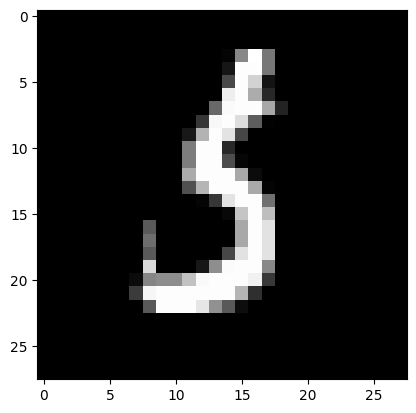

Prediction: [8]
Label: 8


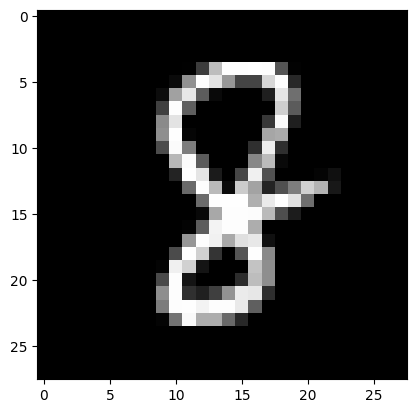

Prediction: [3]
Label: 3


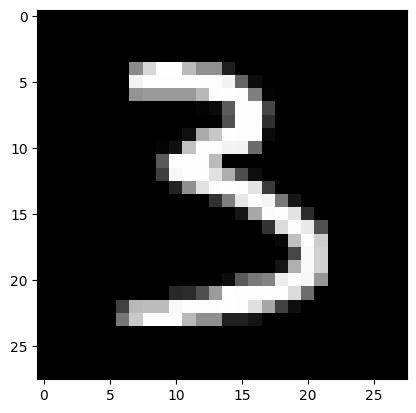

Prediction: [6]
Label: 6


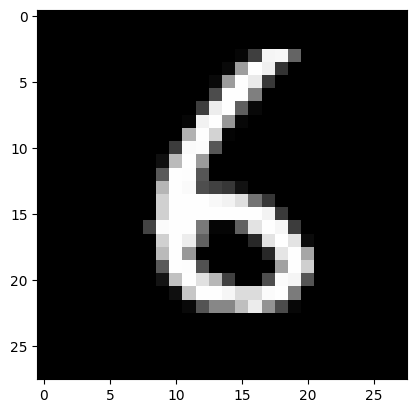

In [119]:
test_prediction(0, W1, b1, W2, b2, W3, b3)
test_prediction(1, W1, b1, W2, b2, W3, b3)
test_prediction(2, W1, b1, W2, b2, W3, b3)
test_prediction(3, W1, b1, W2, b2, W3, b3)

In [145]:
dev_predictions = make_predictions(X_train,W1,b1,W2,b2,W3,b3)
get_accuracy(dev_predictions, Y_label_train)

np.float64(0.9274761904761905)